In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("../data/rock_density_xray.csv")

In [4]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [ ]:
df.columns = ['Signal',"Density"]

<Axes: xlabel='Signal', ylabel='Density'>

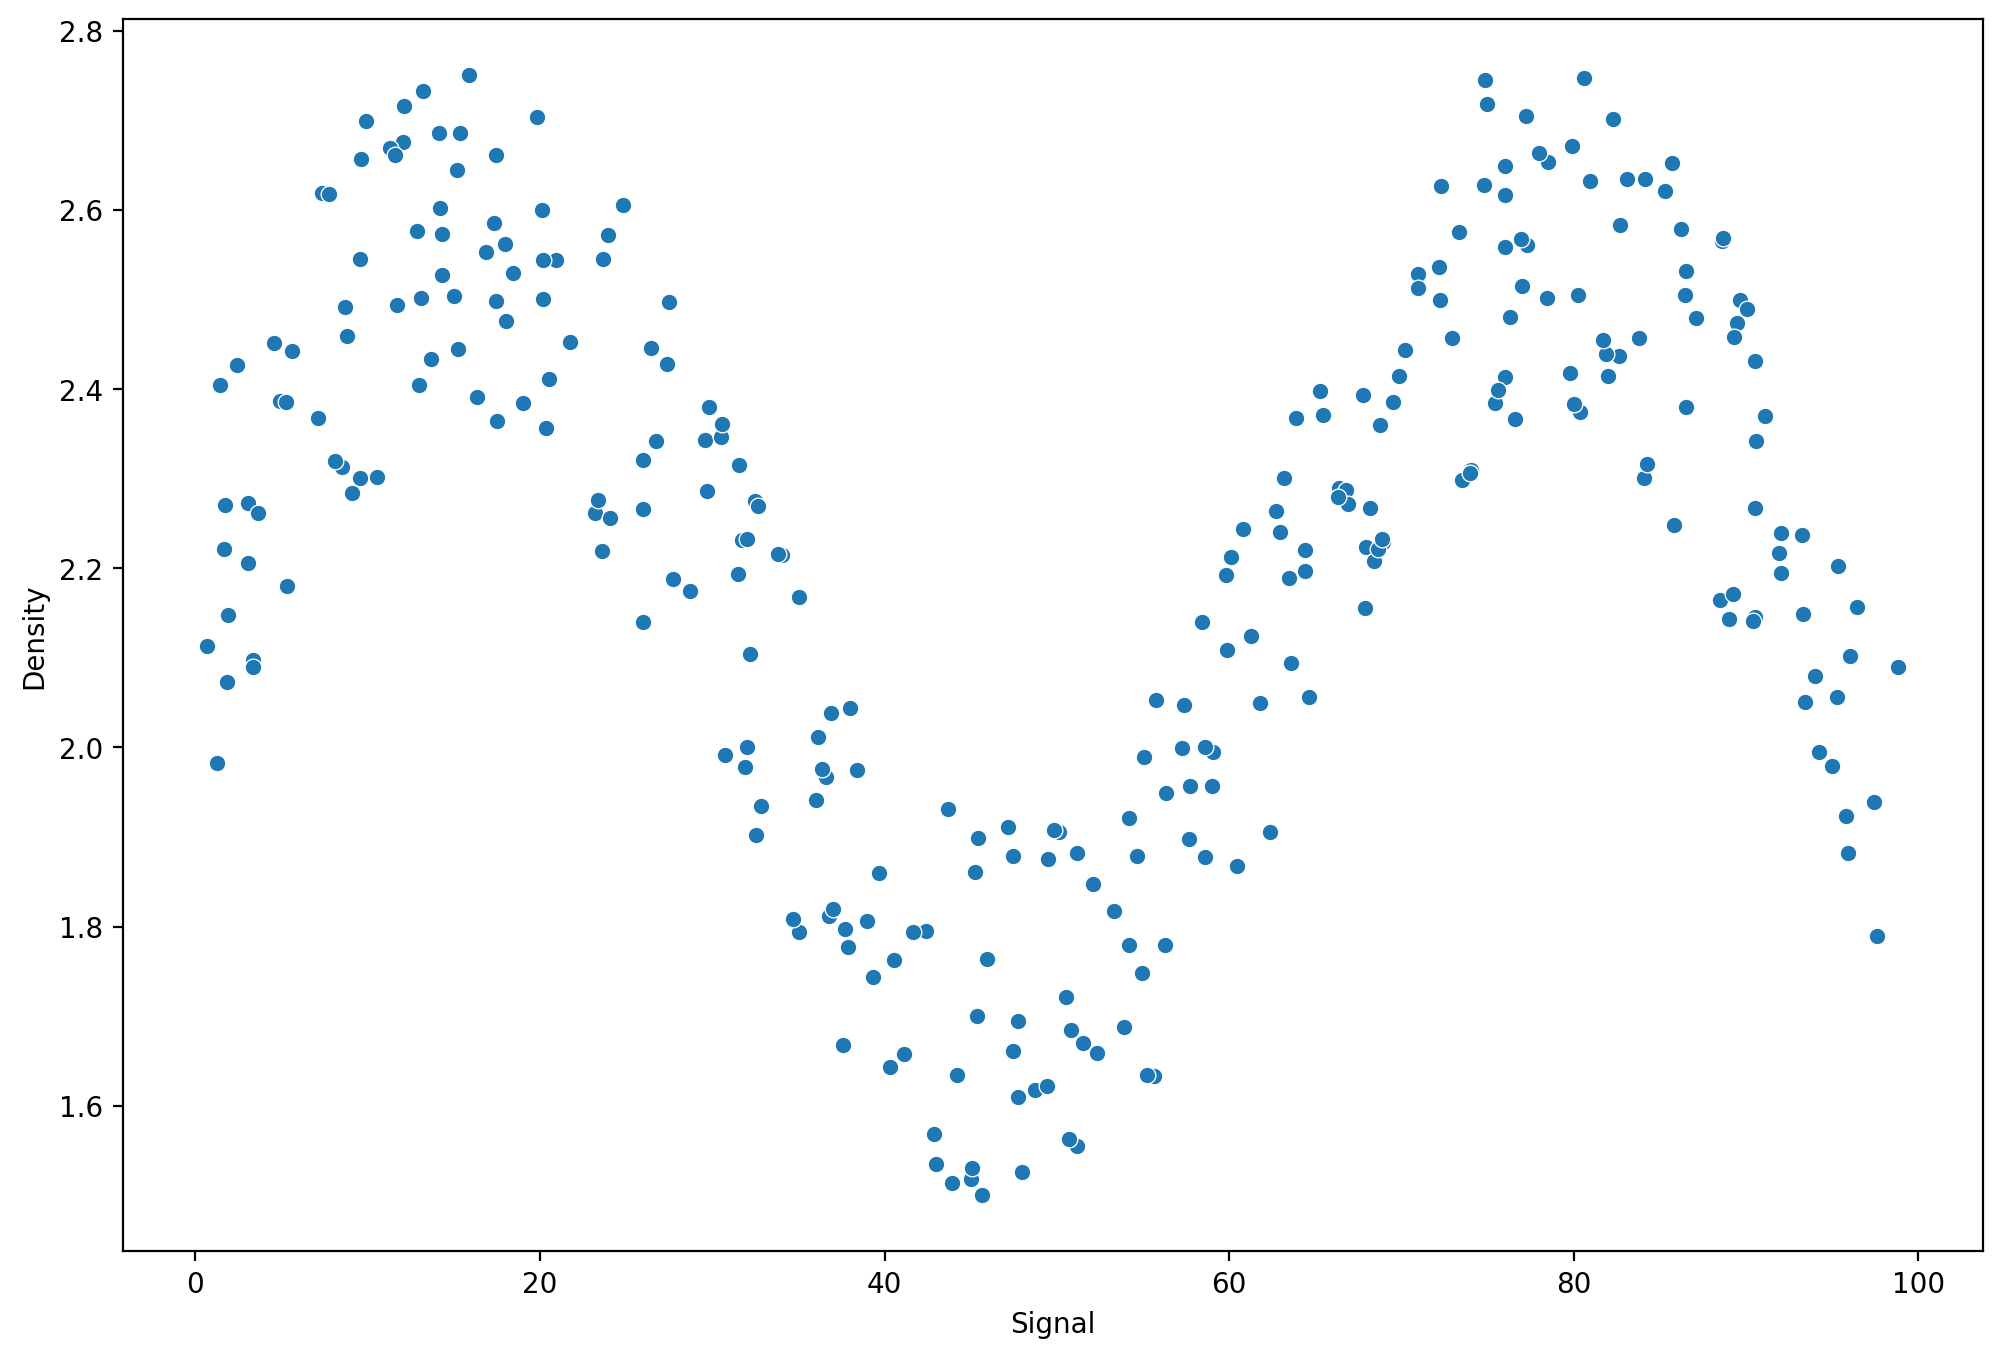

In [6]:
plt.figure(figsize=(12, 8), dpi=200)
sns.scatterplot(x='Signal', y='Density',data=df)

## Splitting the Data

Let's split the data in order to be able to have a Test set for performance metric evaluation.

In [7]:
X = df['Signal'].values.reshape(-1, 1)
y = df['Density']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=101)

In [10]:

# Linear Regression

from sklearn.linear_model import LinearRegression

In [11]:
lr_model = LinearRegression()

In [12]:
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
lr_preds = lr_model.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error

In [16]:
np.sqrt(mean_squared_error(y_test, lr_preds))


np.float64(0.2570051996584629)

In [17]:
signal_range = np.arange(0, 100)

In [18]:
lr_output = lr_model.predict(signal_range.reshape(-1, 1))

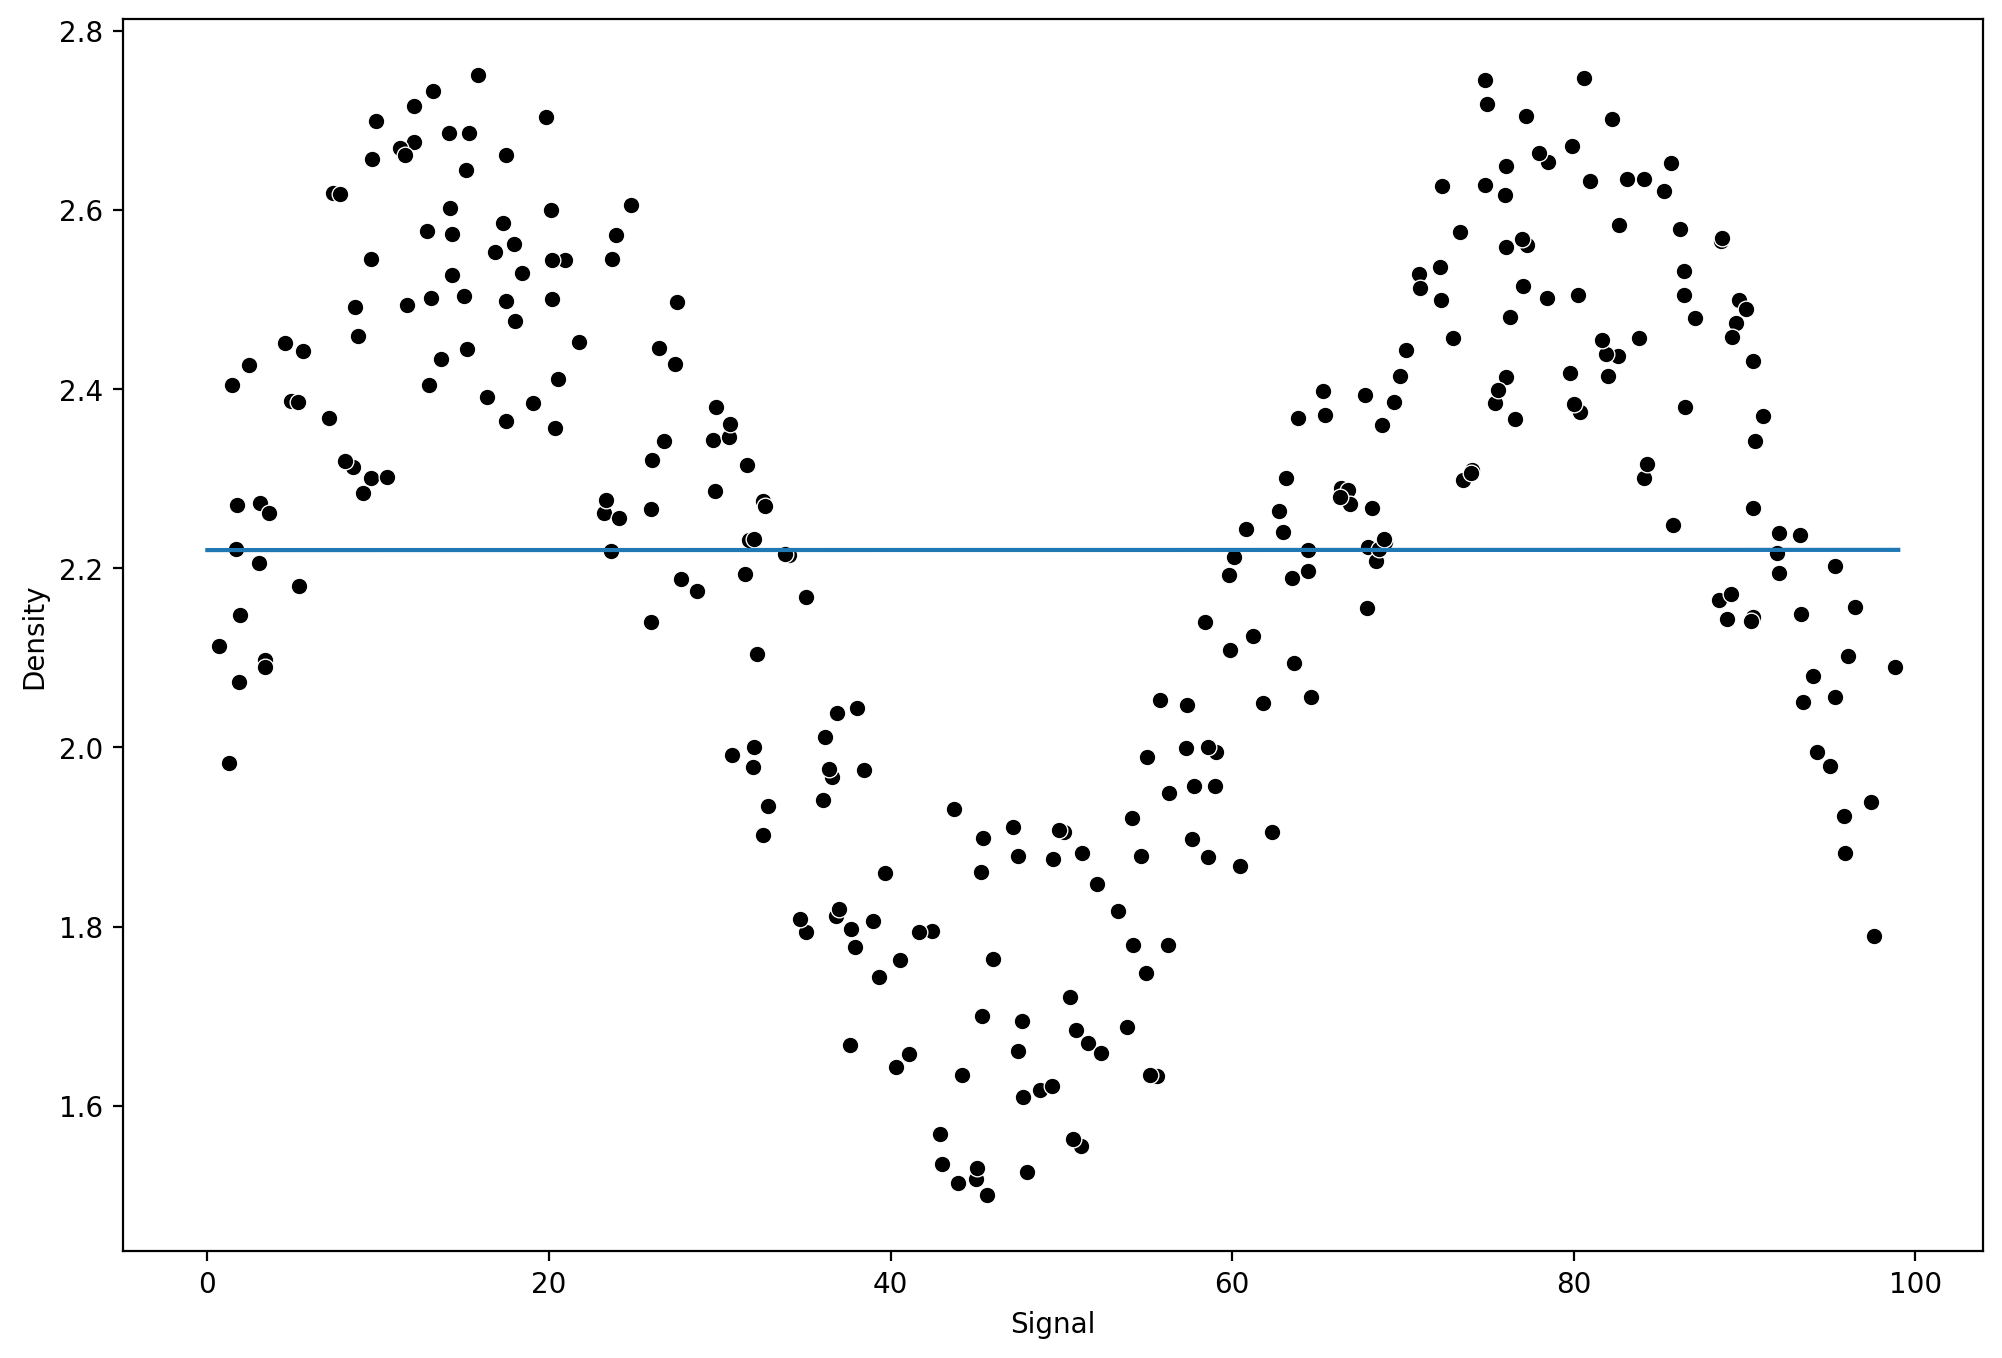

In [20]:
plt.figure(figsize=(12, 8), dpi=200)
sns.scatterplot(x='Signal', y='Density', data=df, color='black')
plt.plot(signal_range, lr_output)

In [ ]:
## Attempting with a Polynomial Regression Model

# Let's explore why our standard regression approach of a polynomial could be difficult to fit here, keep in mind, we're in a fortunate situation where we can easily visualize results of y vs x.

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [24]:
def run_model(model, X_train, y_train, X_test, y_test):

    # Fit Model
    model.fit(X_train, y_train)

    # Get Metrics

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f'RMSE : {rmse}')

    # Plot results
    signal_range = np.arange(0, 100)
    output = model.predict(signal_range.reshape(-1, 1))

    plt.figure(figsize=(12, 6), dpi=150)
    sns.scatterplot(x='Signal', y='Density', data=df, color='black')
    plt.plot(signal_range, output)

RMSE : 0.2570051996584629


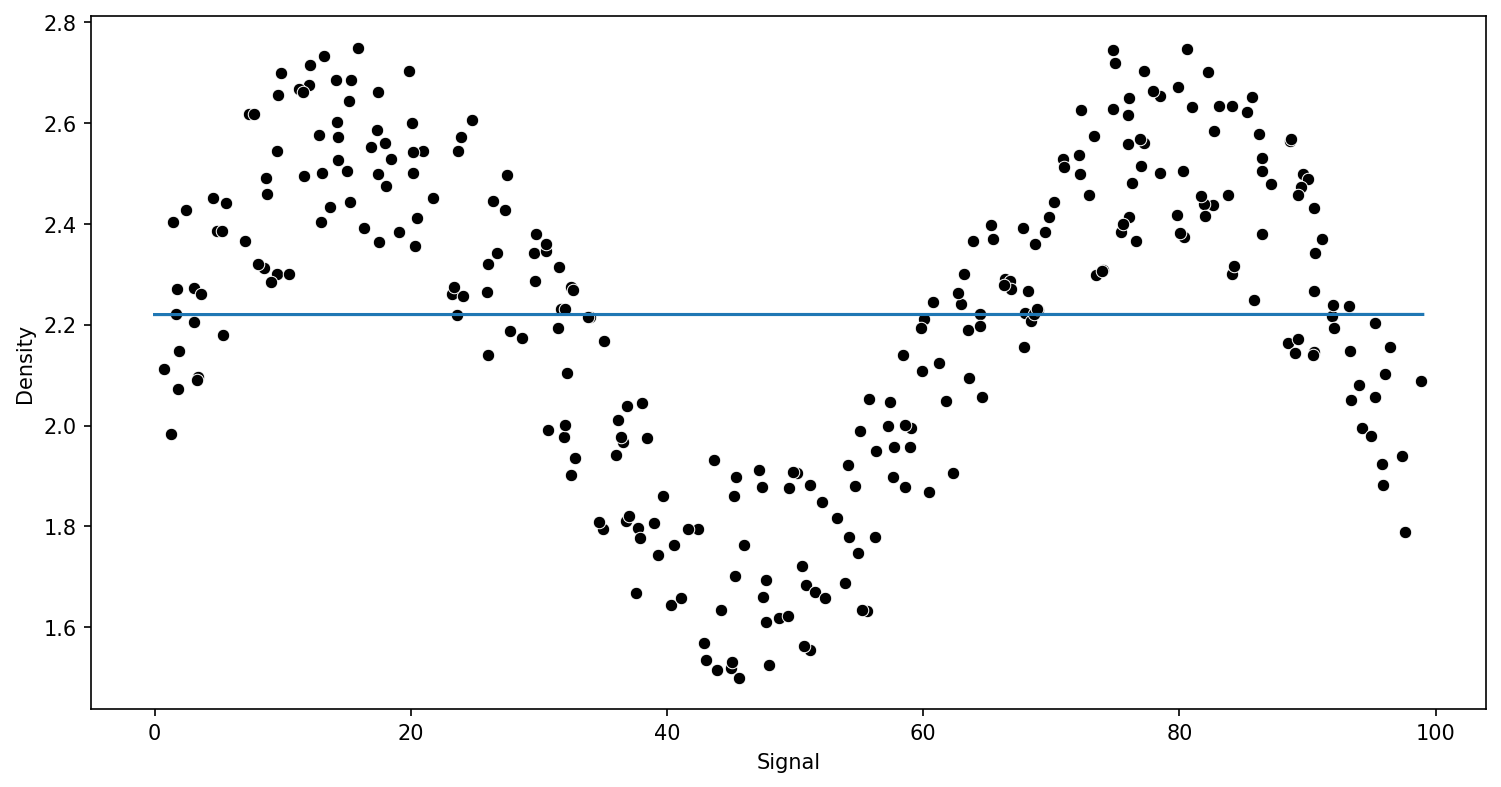

In [25]:
run_model(model, X_train,y_train,X_test,y_test)

In [26]:
from sklearn.pipeline import make_pipeline

In [27]:
from sklearn.preprocessing import PolynomialFeatures

In [28]:
pipe = make_pipeline(PolynomialFeatures(2), LinearRegression())

RMSE : 0.2817309563725596


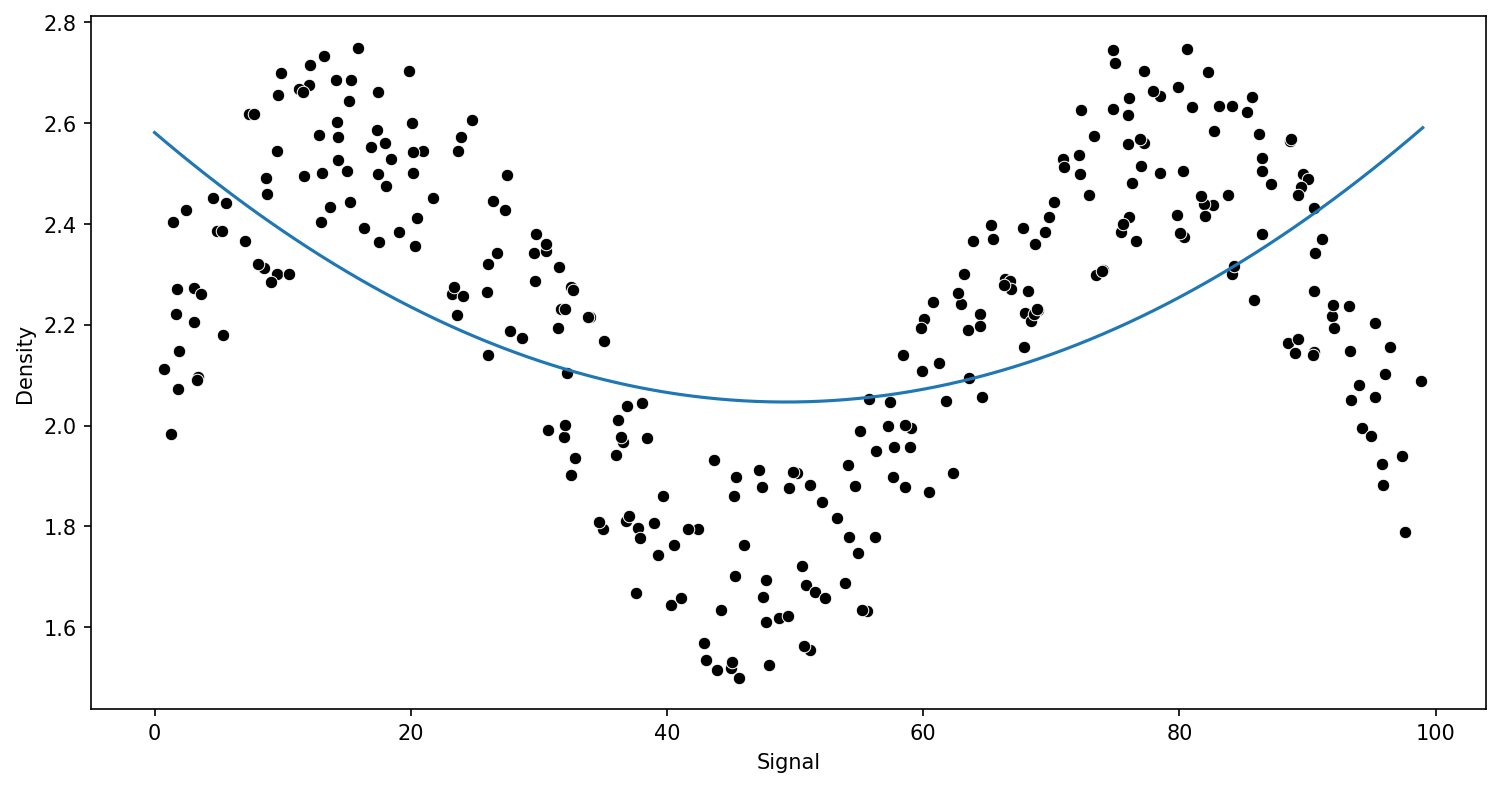

In [29]:
run_model(pipe, X_train,y_train,X_test,y_test)

In [ ]:
# Comparing Various Polynomial Orders

RMSE : 0.16269005292854596


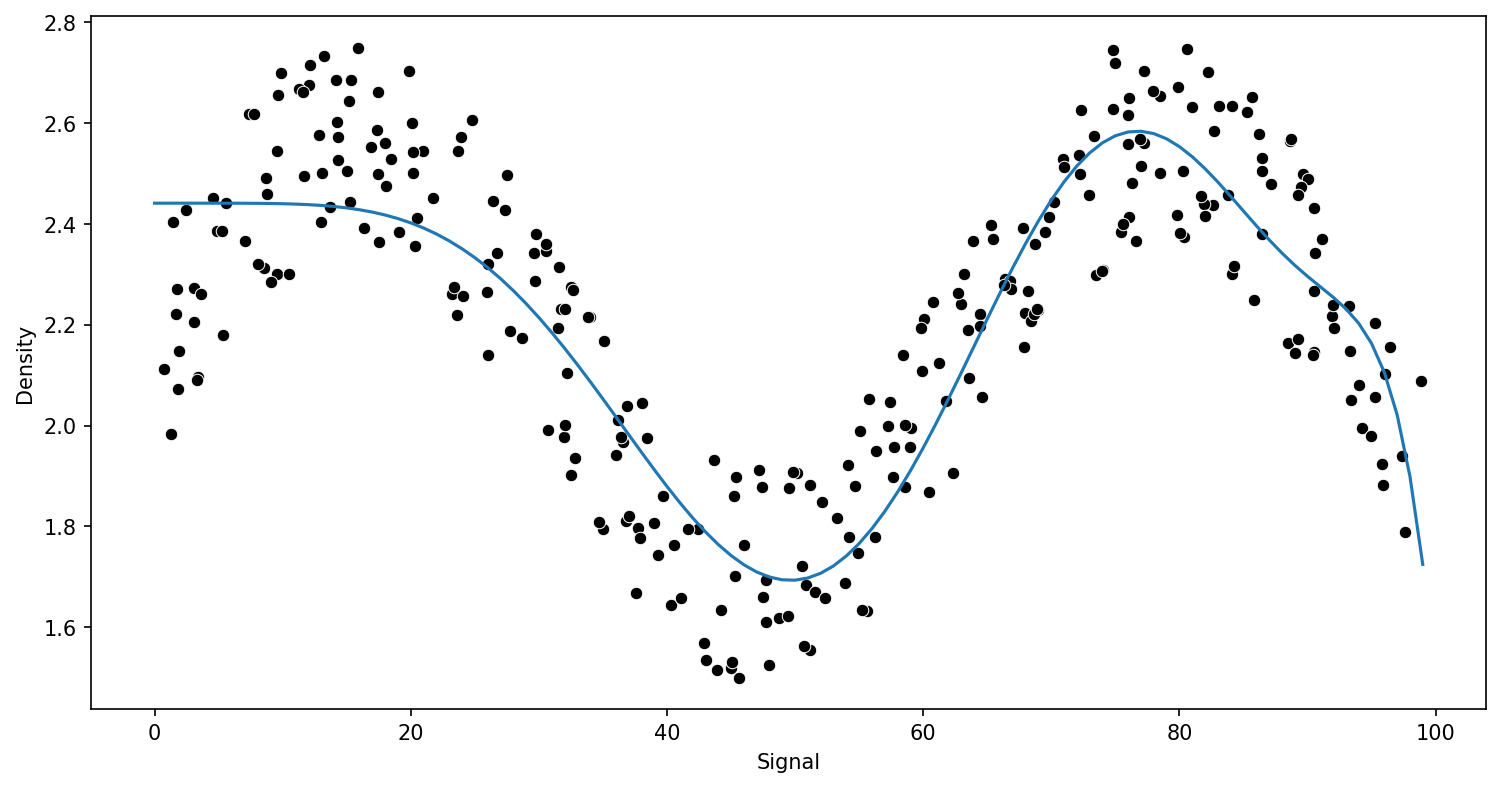

In [30]:
pipe = make_pipeline(PolynomialFeatures(10), LinearRegression())
run_model(pipe, X_train,y_train,X_test,y_test)

In [31]:

# KNN Regression

from sklearn.neighbors import KNeighborsRegressor

RMSE : 0.1523487028635337
RMSE : 0.13730685016923647
RMSE : 0.13277855732740926


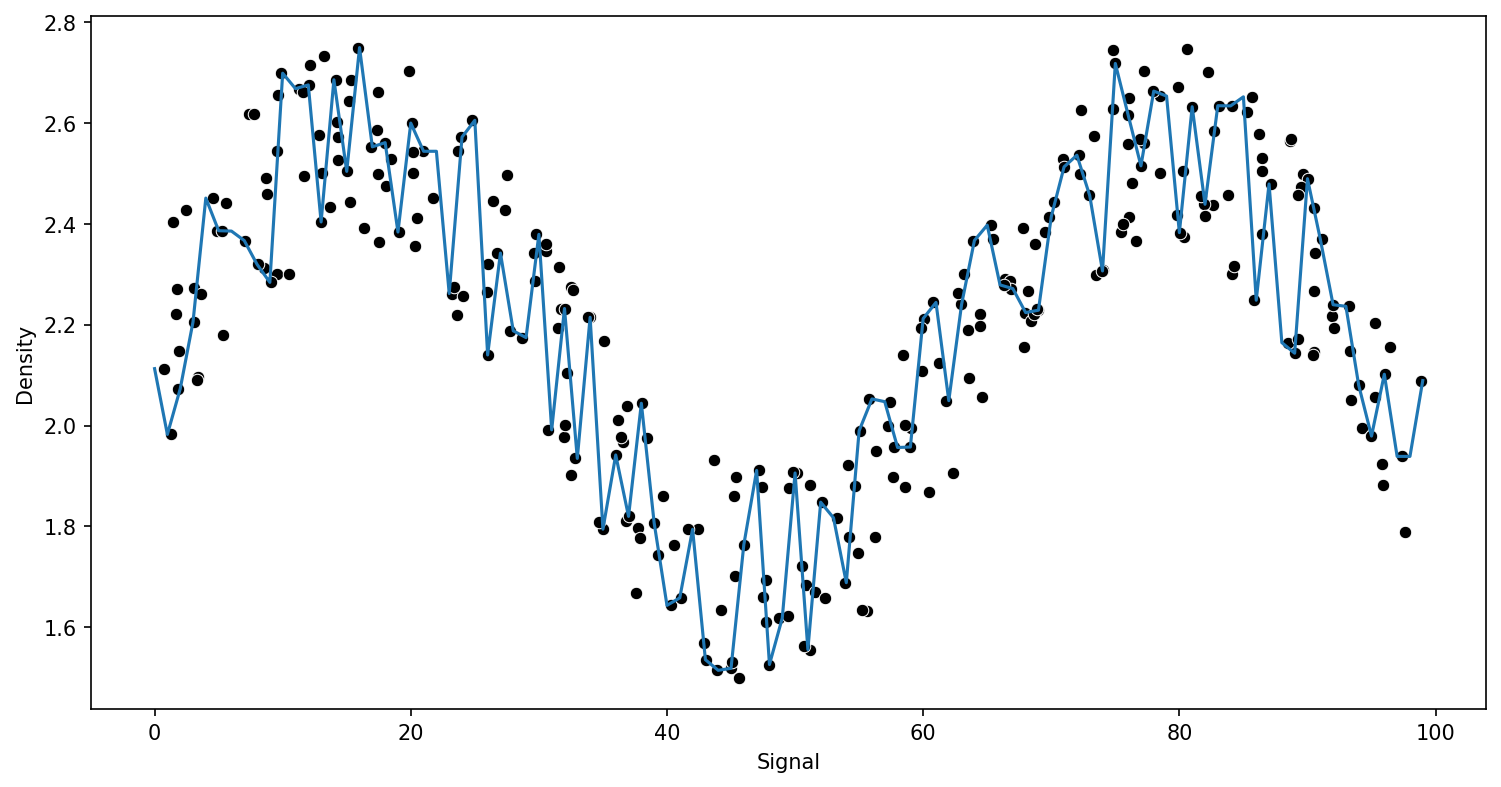

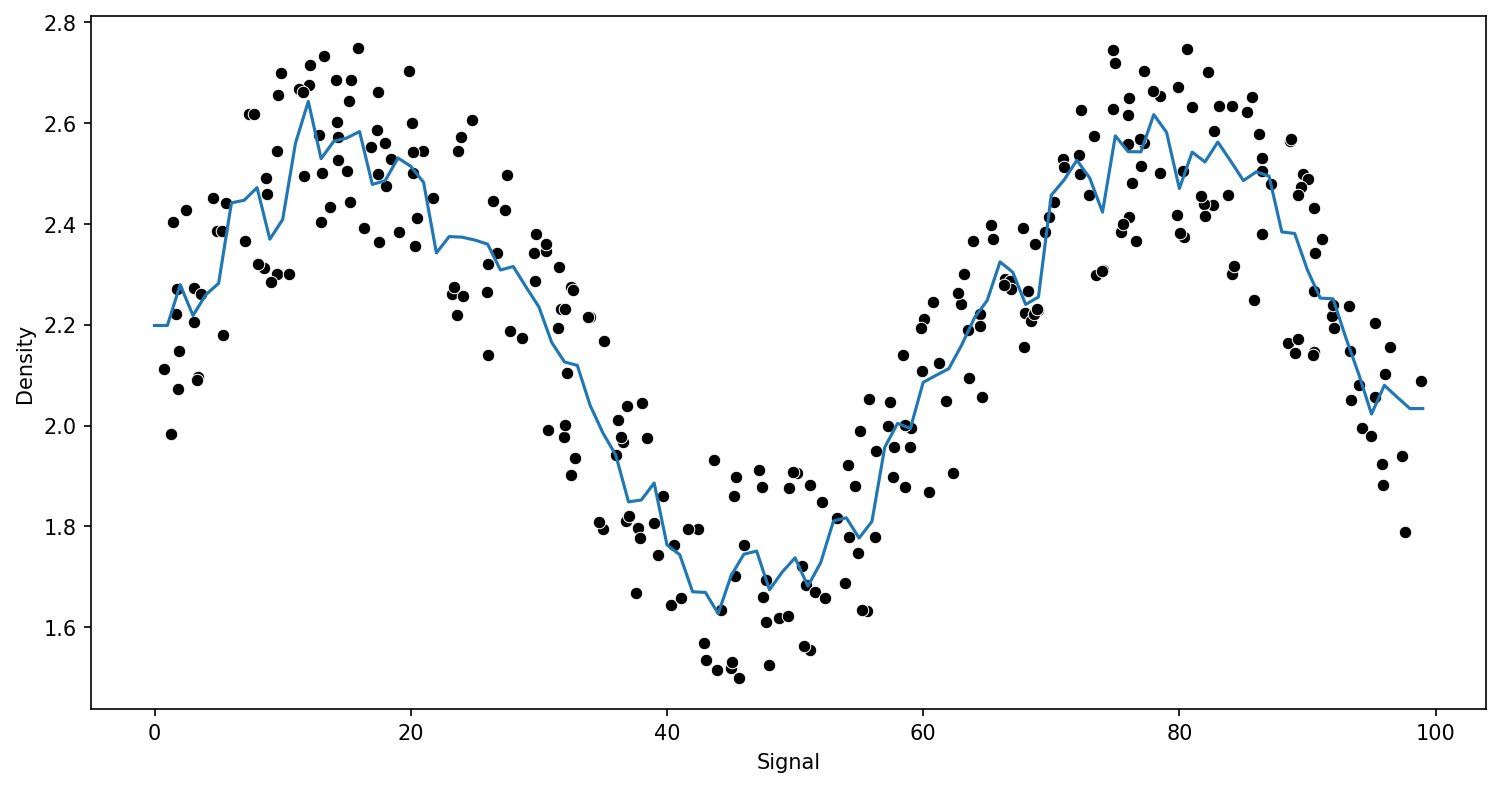

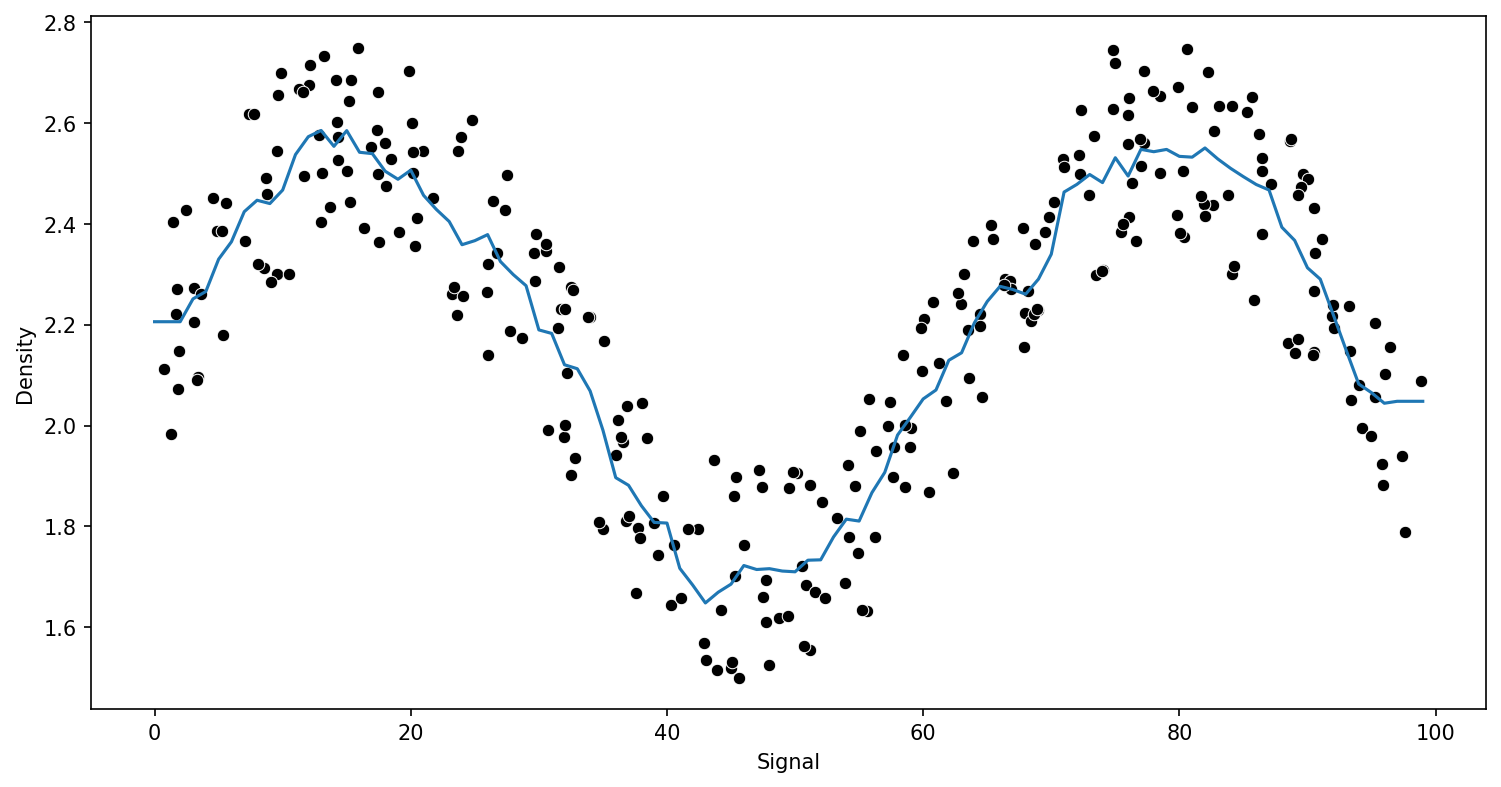

In [32]:
preds = {}
k_values = [1, 5, 10]
for n in k_values:

    model = KNeighborsRegressor(n_neighbors=n)
    run_model(model, X_train,y_train,X_test,y_test)

In [33]:

## Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor

RMSE : 0.1523487028635337


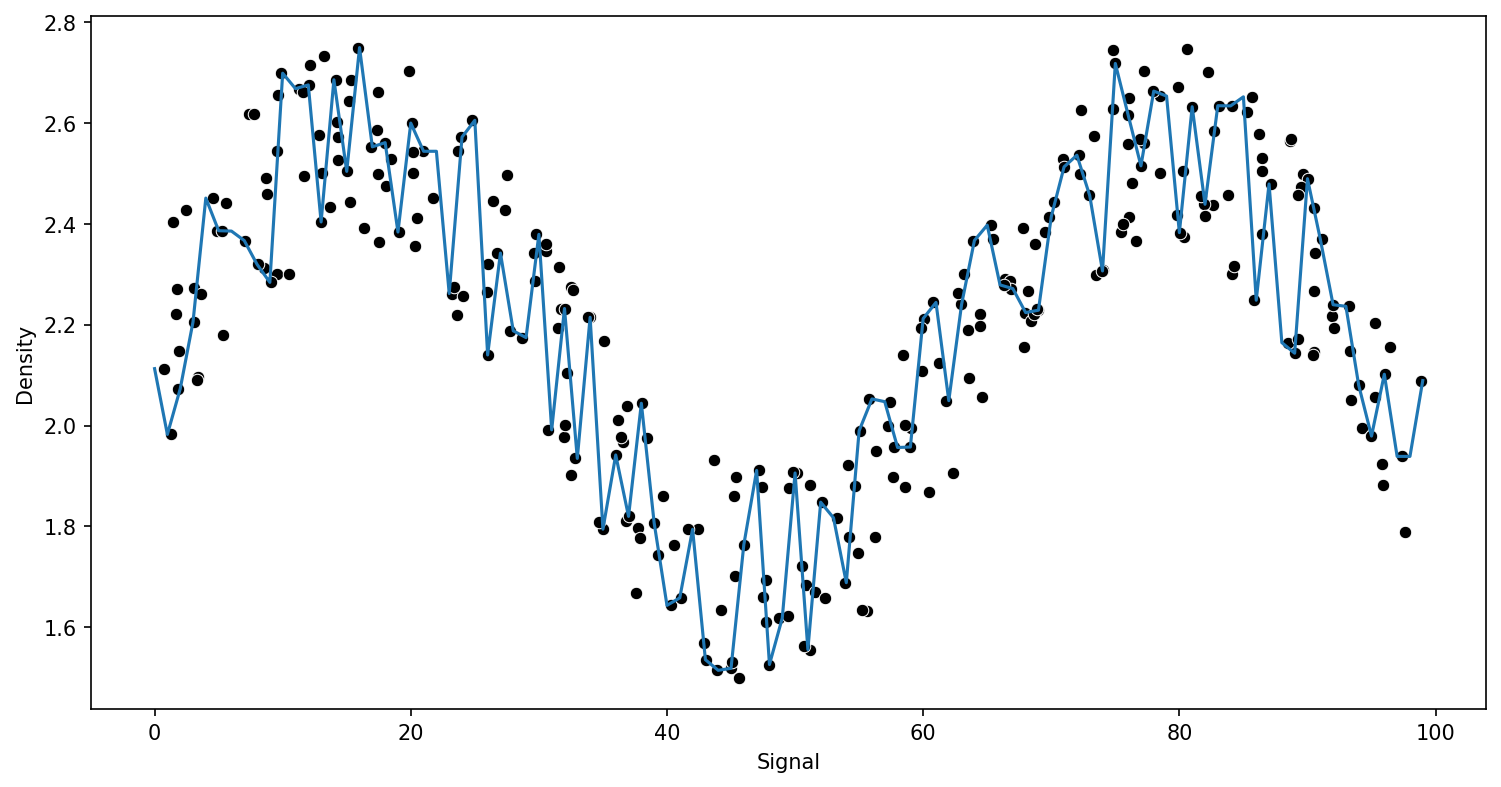

In [34]:
model = DecisionTreeRegressor()

run_model(model,X_train,y_train,X_test,y_test)

In [ ]:
# Support Vector Regression

In [35]:
from sklearn.svm import SVR

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
param_grid = {'C': [0.01, 0.1, 1, 5, 10, 100, 1000],
              'gamma': ['auto', 'scale']}
svr = SVR()

In [38]:
grid = GridSearchCV(svr, param_grid)

RMSE : 0.12646999302046696


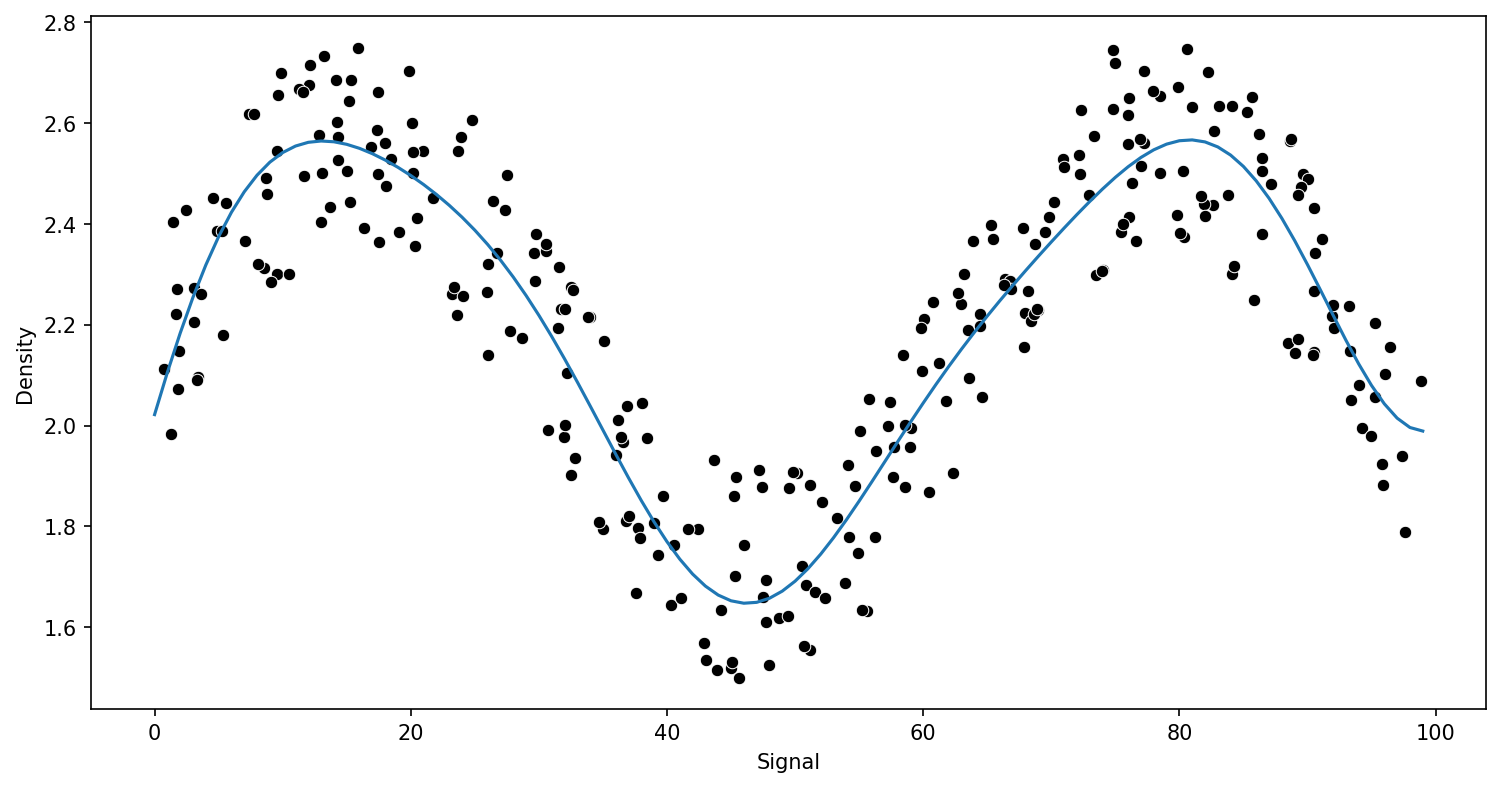

In [39]:
run_model(grid, X_train,y_train,X_test,y_test)

In [40]:
grid.best_estimator_

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1000
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [41]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

RMSE : 0.1327530962043384
RMSE : 0.13452352985653176
RMSE : 0.13497579120502431


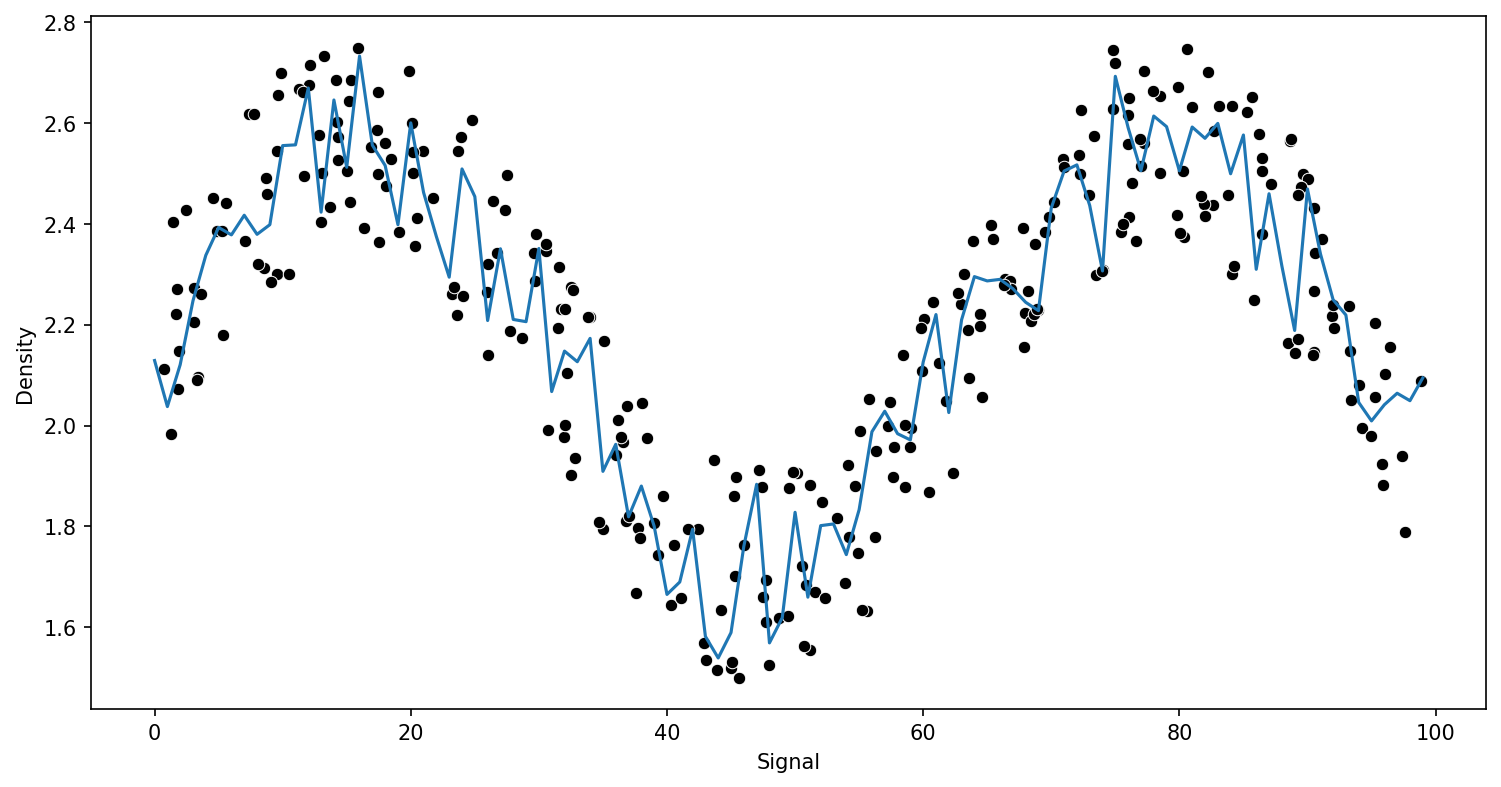

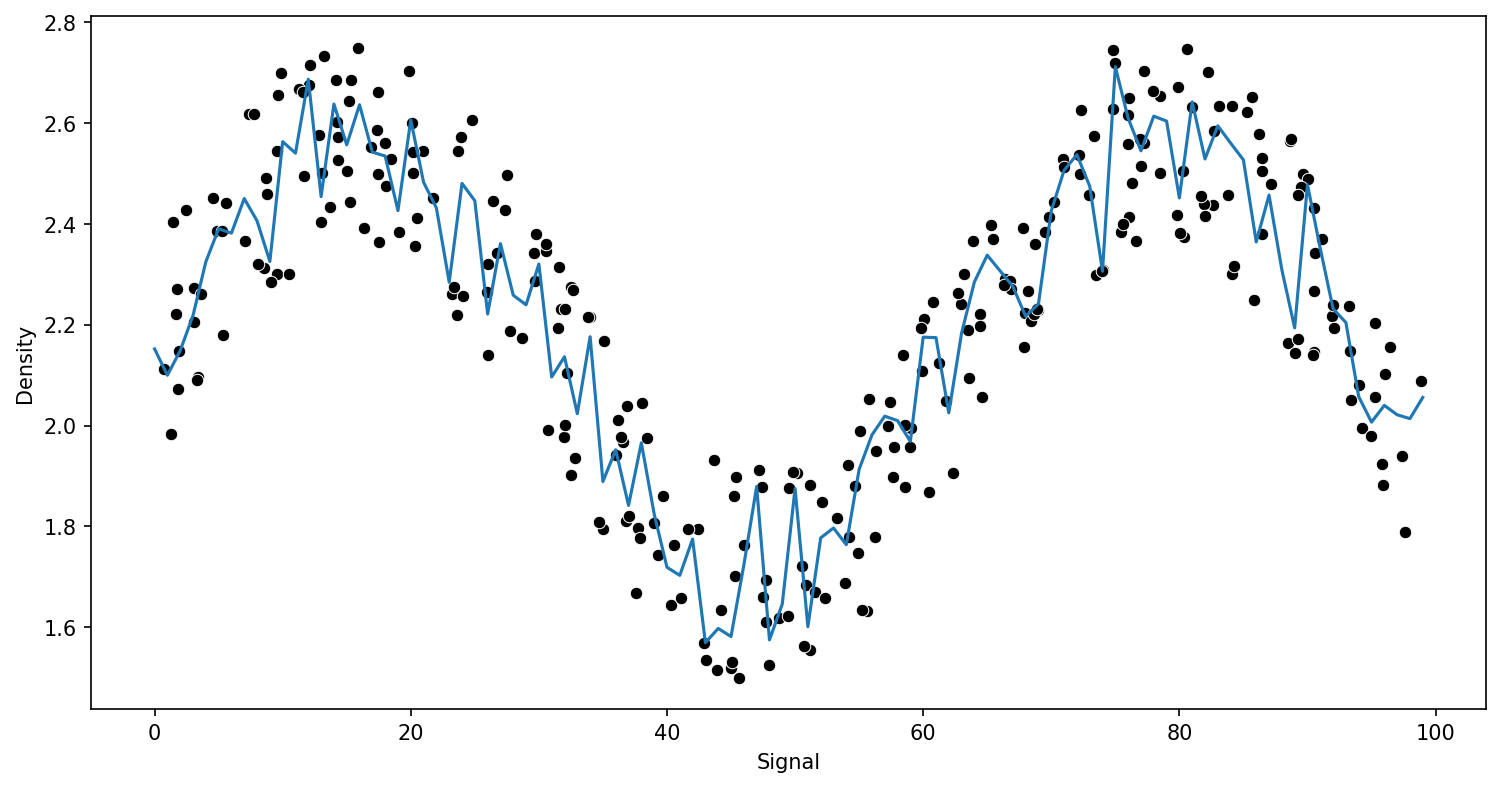

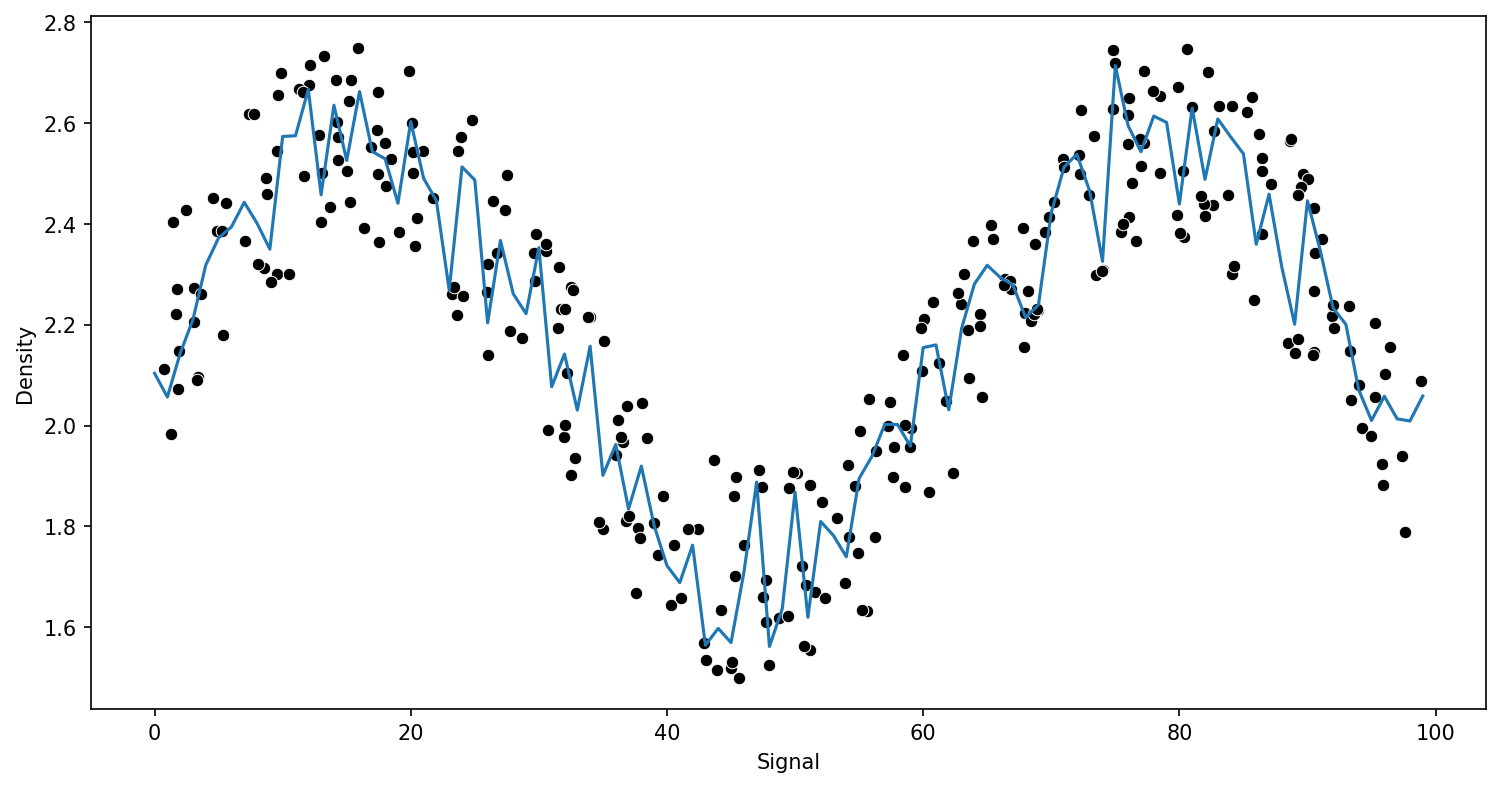

In [42]:
trees = [10, 50, 100]
for n in trees:

    model = RandomForestRegressor(n_estimators=n)

    run_model(model, X_train,y_train,X_test,y_test)

In [ ]:
# Gradient Boosting

In [43]:
from sklearn.ensemble import GradientBoostingRegressor

RMSE : 0.13294148649584667


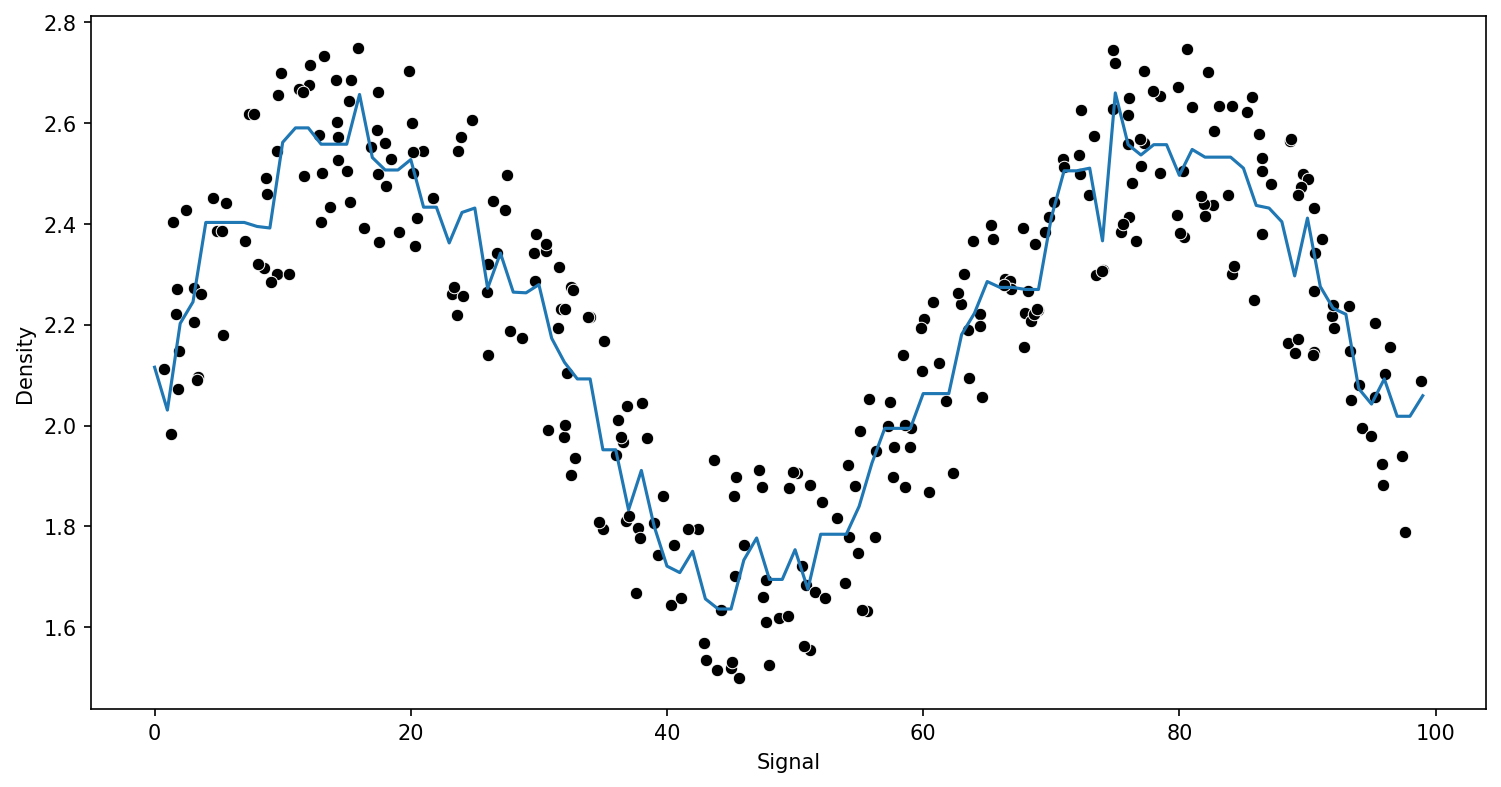

In [44]:

model = GradientBoostingRegressor()

run_model(model, X_train,y_train,X_test,y_test)

In [45]:
# Adaboost
from sklearn.ensemble import AdaBoostRegressor

RMSE : 0.13294148649584667


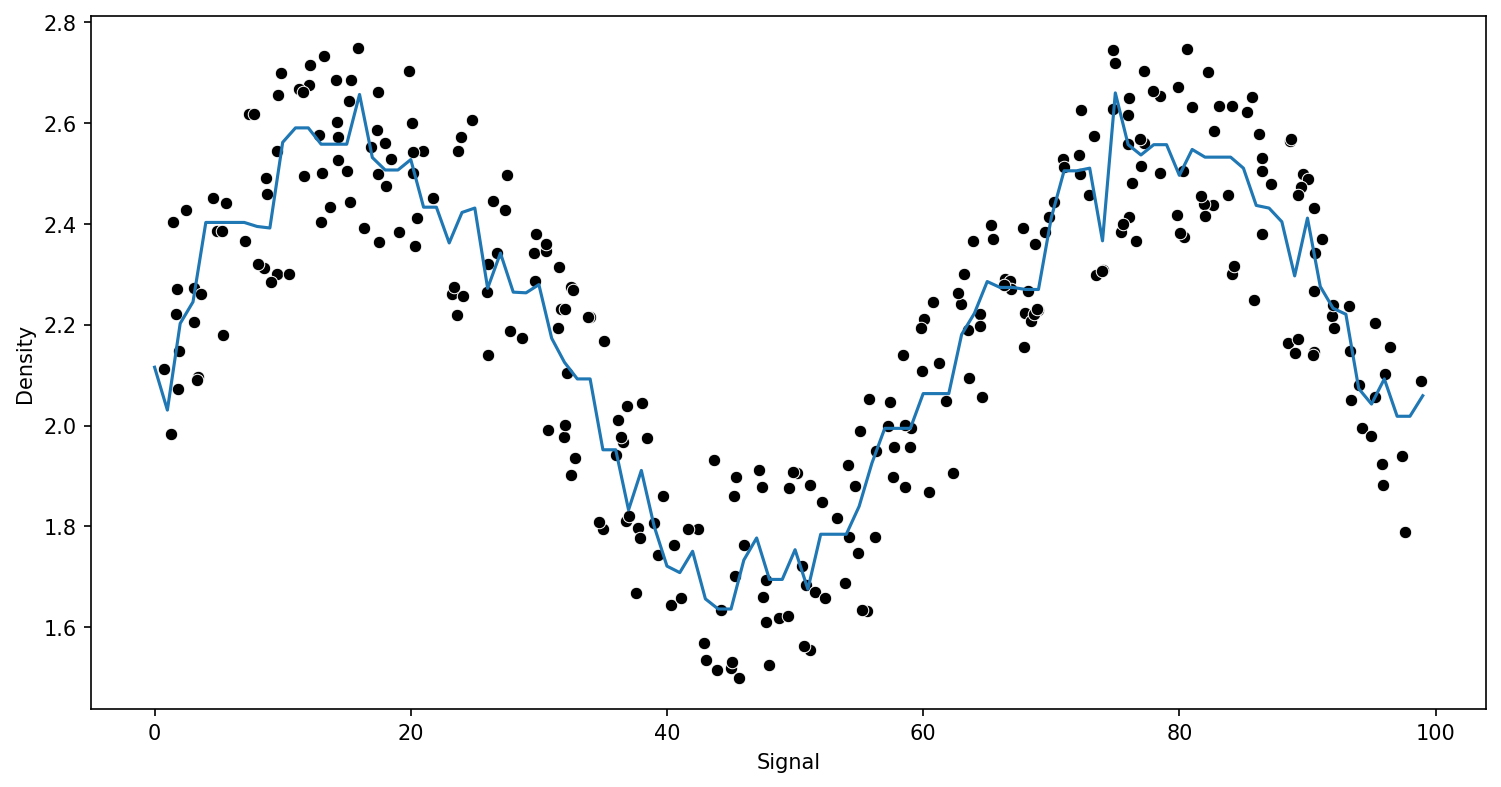

In [46]:
model = GradientBoostingRegressor()

run_model(model, X_train,y_train,X_test,y_test)